# Introduction to Data Science 2026

# Week 3

## Exercise 1 | Working with geospatial data (GIS)

To get at least a bit familiar with [GIS](https://en.wikipedia.org/wiki/Geographic_information_system) data and the concept of map projections, we’ll do a simple task of plotting two data sets that are given in different coordinate systems.

1. Download the [world_m.zip](https://github.com/HY-TKTL/intro-to-data-science-2017/blob/master/world_m.zip) and [cities.zip](https://github.com/HY-TKTL/intro-to-data-science-2017/blob/master/cities.zip) files that each include a set of GIS files. Most notably, the <span style="font-weight: bold">shp</span> files are [Shapefile-files](https://en.wikipedia.org/wiki/Shapefile) with coordinates (don’t look, it’s binary!). The <span style="font-weight: bold">prj</span> files contain information (in plain text, so okay to look) about the coordinate systems. Open the files using your favorite programming environment and packages.  

    <span style="font-weight: 500"> *Hint: We warmly recommend [Geopandas](http://geopandas.org/) for pythonistas.*</span>

In [5]:
import geopandas as gpd
import matplotlib.pyplot as plt

world = gpd.read_file('world_m/world_m.shp')
cities = gpd.read_file('cities/cities.shp')

print("World Dataset:")
print(f"Shape: {world.shape}")
print(f"CRS: {world.crs}")
print(world.head())

print("Cities Dataset:")
print(f"Shape: {cities.shape}")
print(f"CRS: {cities.crs}")
print(cities.head())

World Dataset:
Shape: (174, 7)
CRS: EPSG:3395
      pop_est      continent                  name iso_a3  gdp_md_est  \
0  28400000.0           Asia           Afghanistan    AFG     22270.0   
1  12799293.0         Africa                Angola    AGO    110300.0   
2   3639453.0         Europe               Albania    ALB     21810.0   
3   4798491.0           Asia  United Arab Emirates    ARE    184300.0   
4  40913584.0  South America             Argentina    ARG    573900.0   

   gdp_per_ca                                           geometry  
0    0.000784  POLYGON ((6813956.99 4227673.562, 6927484.435 ...  
1    0.008618  MULTIPOLYGON (((1817460.823 -651055.118, 18449...  
2    0.005993  POLYGON ((2292095.859 5110825.73, 2277950.23 5...  
3    0.038408  POLYGON ((5741805.754 2765811.385, 5761611.935...  
4    0.014027  MULTIPOLYGON (((-7291426.647 -7365665.131, -73...  
Cities Dataset:
Shape: (202, 2)
CRS: EPSG:4326
           name                   geometry
0  Vatican City  POINT 

2. The <span style="font-weight: bold">world_m</span> file contains borders of almost all countries in the world. Plot the world.

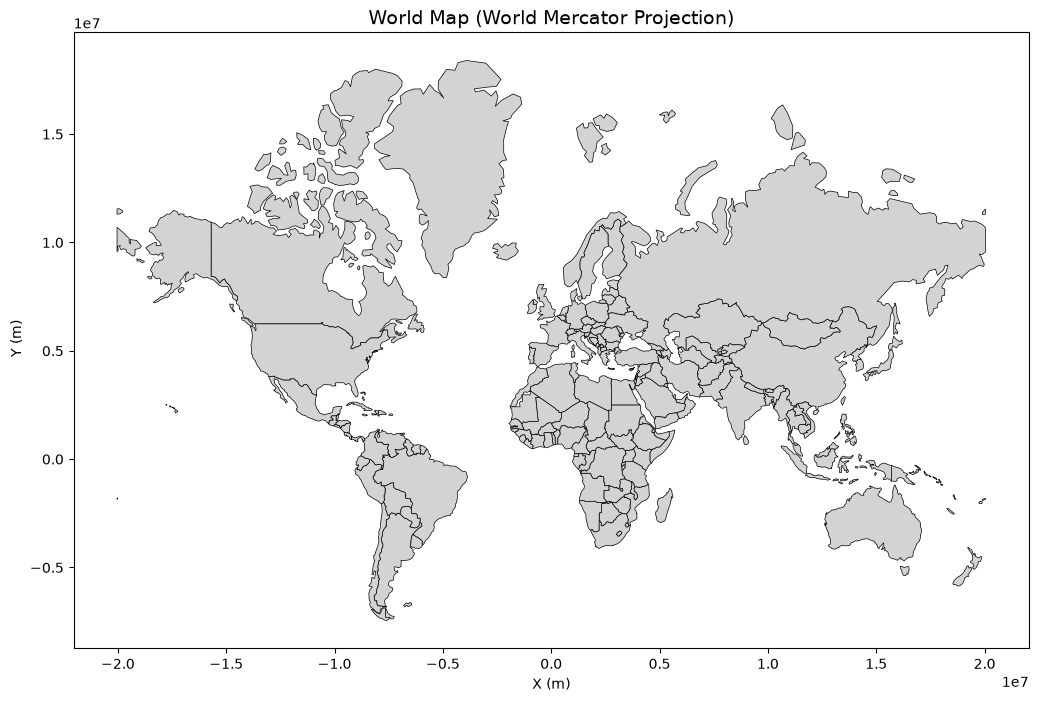

In [12]:
fig, ax = plt.subplots(figsize=(14, 8))
world.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)
ax.set_title("World Map (World Mercator Projection)", fontsize=14)
ax.set_xlabel("X (m)")
ax.set_ylabel(" Y (m)")
plt.show()

3. On top of the countries that you just plotted, plot another layer of information, namely the capital cities of each country from the <span style="font-weight: bold">cities</span> dataset. However, depending on how clever your programming environment is, the cities will probably all appear to be in the Gulf of Guinea, near the coordinates (0°, 0°).

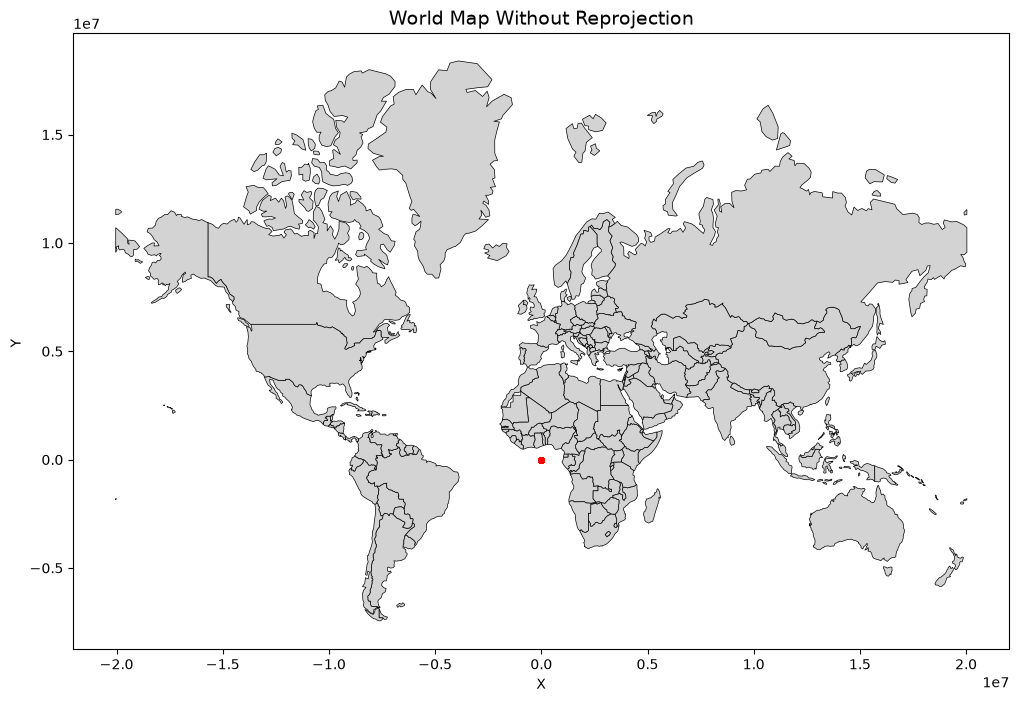

In [11]:
fig, ax = plt.subplots(figsize=(14, 8))
world.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)
cities.plot(ax=ax, color='red', markersize=15, alpha=0.7)
ax.set_title("World Map Without Reprojection", fontsize=14)
ax.set_xlabel("X")
ax.set_ylabel("Y ")
plt.show()

4. Perform a map projection to bring the two data-sets into a shared coordinate system. (You can choose which one.) Now plot the two layers together to make sure the capital cities are where they are supposed to be.

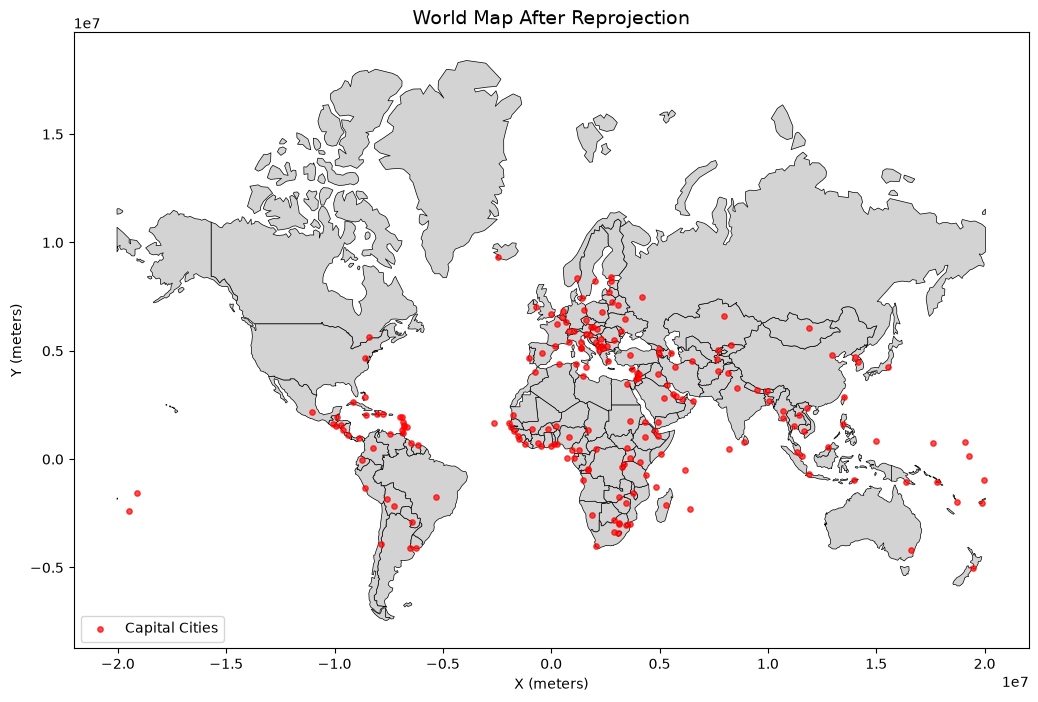

In [14]:
cities_projected = cities.to_crs(world.crs)

fig, ax = plt.subplots(figsize=(14, 8))
world.plot(ax=ax, color='lightgray', edgecolor='black', linewidth=0.5)
cities_projected.plot(ax=ax, color='red', markersize=15, alpha=0.7, label='Capital Cities')
ax.set_title("World Map After Reprojection", fontsize=14)
ax.set_xlabel("X (meters)")
ax.set_ylabel("Y (meters)")
ax.legend(loc="lower left")
plt.show()

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**

## Exercise 2 | Symbol classification

We’ll be looking into machine learning by checking out the [HASYv2](https://zenodo.org/record/259444#.Wb7efZ8xDhZ) dataset that contains hand written mathematical symbols as images. The whole dataset is quite big, so we’ll restrict ourselves to doing 10-class classification on some of the symbols. Download the data and complete the following tasks.

1. Extract the data and find inside a file called <span style="font-weight: bold">hasy-data-labels.csv</span>. This file contains the labels for each of the images in the <span style="font-weight: bold">hasy_data</span> folder. Read the labels in and only keep the rows where the <span style="font-weight: bold">symbol_id</span> is within the inclusive range <span style="font-weight: bold">[70, 79]</span>. Read the corresponding images as black-and-white images and flatten them so that each image is a single vector of shape <span style="font-weight: bold">32x32 = 1024</span>. Your dataset should now consist of your input data of shape <span style="font-weight: bold">(1020, 1024)</span> and your labels of shape <span style="font-weight: bold">(1020, )</span>. That is, a matrix of shape <span style="font-weight: bold">1020 x 1024</span> and a vector of size <span style="font-weight: bold">1020</span>.

In [16]:
import os
import numpy as np
import pandas as pd
from PIL import Image
import matplotlib.pyplot as plt


base_dir = 'HASYv2' if os.path.exists('HASYv2/hasy-data-labels.csv') else '.'
csv_path = os.path.join(base_dir, 'hasy-data-labels.csv')
df = pd.read_csv(csv_path)

filtered_df = df[(df['symbol_id'] >= 70) & (df['symbol_id'] <= 79)].copy()
X_list = []
y_list = []

for _, row in filtered_df.iterrows():
    img_path = os.path.join(base_dir, row['path'])
    img = Image.open(img_path).convert('L')     
    img_arr = np.array(img, dtype=np.float32)  
    X_list.append(img_arr.flatten())            
    y_list.append(row['symbol_id'])

X = np.array(X_list)
y = np.array(y_list)

print(f"x shape: {X.shape}")
print(f"y shape: {y.shape}")

x shape: (1020, 1024)
y shape: (1020,)


2. Randomly shuffle the data, and then split it into training and test sets, using the first 80% of the data for training and the rest for evaluation.

In [17]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split( X, y, test_size=0.20, random_state=42, shuffle=True, stratify=y)
print(f"Training set-  X_train shape = {X_train.shape}, y_train shape = {y_train.shape}")
print(f"Test set-  X_test shape  = {X_test.shape}, y_test shape  = {y_test.shape}")

Training set-  X_train shape = (816, 1024), y_train shape = (816,)
Test set-  X_test shape  = (204, 1024), y_test shape  = (204,)


3. Fit a logistic regression classifier on the data. Note that we have a multi-class classification problem, but logistic regression is a binary classifier. For this reason, you will find useful <span style="font-weight: bold">[Sklearn's "multi_class" attribute](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html)</span>. Use a multinomial loss and the softmax function to predict the probability of each class as the outcome.  The classifier should select the class with the highest probability. Most library implementations will do this for you - feel free to use one.

In [19]:
from sklearn.linear_model import LogisticRegression
model = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance, default=NoneOnly used for `solver` == 'sag', 'saga' or 'liblinear' to shuffle thedata. It has no effect on the other solvers.See :term:`Glossary <random_state>` for details.",42
,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in 

4. In order to evaluate the model, let’s create our own dummy classifier that simply guesses the most common class in the training set (looking at the test set here would be cheating!). Then, evaluate your logistic regression model on the test data, and compare it to the majority class classifier. The logistic regression model should have significantly better accuracy as the dummy model is merely making a guess.

    <span style="font-weight: 500"> *Hint: Sklearn's DummyClassifier( ) might save you a bit of time.*</span>

In [20]:
from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, classification_report
dummy = DummyClassifier(strategy='most_frequent')
dummy.fit(X_train, y_train)


y_pred_lr = model.predict(X_test)
y_pred_dummy = dummy.predict(X_test)

acc_lr = accuracy_score(y_test, y_pred_lr)
acc_dummy = accuracy_score(y_test, y_pred_dummy)

print(f"Logistic Regression Test Accuracy: {acc_lr * 100:.2f}%")
print(f"Dummy Accuracy:   {acc_dummy * 100:.2f}%\n")
print("--- Classification Report (Logistic Regression) ---")
print(classification_report(y_test, y_pred_lr))

Logistic Regression Test Accuracy: 86.76%
Dummy Accuracy:   12.75%

--- Classification Report (Logistic Regression) ---
              precision    recall  f1-score   support

          70       0.96      0.88      0.92        26
          71       0.92      0.96      0.94        24
          72       0.82      0.92      0.87        25
          73       0.85      0.96      0.90        24
          74       0.85      0.92      0.88        12
          75       0.83      0.62      0.71        16
          76       0.86      0.90      0.88        20
          77       0.93      0.87      0.90        15
          78       0.86      0.75      0.80        24
          79       0.79      0.83      0.81        18

    accuracy                           0.87       204
   macro avg       0.87      0.86      0.86       204
weighted avg       0.87      0.87      0.87       204



5. Plot some of the images that the logistic classifier misclassified. Can you think of an explanation why they were misclassified? Would you have gotten them right?
    
    <span style="font-weight: 500">*Hint: Matplotlib has a [function](https://matplotlib.org/stable/api/_as_gen/matplotlib.pyplot.imshow.html) that can help you with plotting.*</span>

Total misclassified test images: 27 / 204


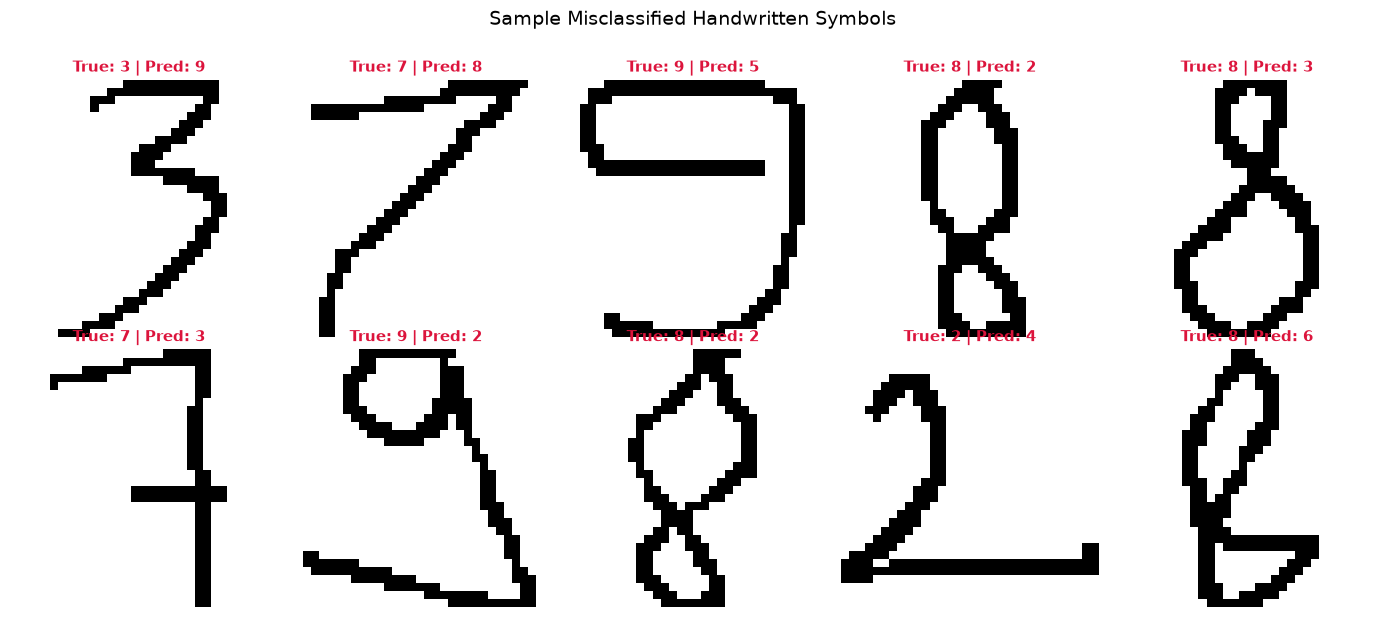

In [ ]:
misclassified = np.where(y_test != y_pred_lr)[0]
print(f"Total misclassified test images: {len(misclassified)} / {len(y_test)}")

symbol_map = {70 + i: str(i) for i in range(10)}
n_plots = min(10, len(misclassified))
fig, axes = plt.subplots(2, 5, figsize=(14, 6))
axes = axes.flatten()

for i in range(n_plots):
    idx = misclassified[i]
    img_vector = X_test[idx]
    img_2d = img_vector.reshape(32, 32)
    
    true_symbol = symbol_map.get(y_test[idx], y_test[idx])
    pred_symbol = symbol_map.get(y_pred_lr[idx], y_pred_lr[idx])
    
    axes[i].imshow(img_2d, cmap="gray")
    axes[i].set_title(f"True: {true_symbol} | Pred: {pred_symbol}", color="crimson", fontsize=11, fontweight="bold")
    axes[i].axis("off")

plt.suptitle("Sample Misclassified Handwritten Symbols", fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

In [ ]:
#The model might have misclasiified becuase of the pixel overlap. Yes, human recognition is better, so i would've gotten them right.

Here are some examples of the syntax used to fit a logistic regression classifier (using Sklearn or statsmodel with Python, or GLM with R):

In [ ]:
#Sklearn (python)

#from sklearn.linear_model import LogisticRegression

#Fit on the training data set, with:
#X : {array-like, sparse matrix}, shape (n_samples, n_features) , n_samples rows x n_features columns
#with attributes that describe each sample.
#y : array-like, shape (n_samples,) , n_samples target values for each sample.

#model = LogisticRegression()
#model.fit(X, y)

In [ ]:
#Statsmodels (python)

#import statsmodels.api as sm
#model = sm.Logit(y, X)

In [ ]:
#GLM (R)

#model <- glm(y ~.,family=binomial(link='logit'), data=X)

In [ ]:
# Use this cell for your code

**Remember to submit your code on the MOOC platform. You can return this Jupyter notebook (.ipynb) or .py, .R, etc depending on your programming preferences.**